In [1]:
import os
import polars as pl
import altair as alt

pl.Config(tbl_rows=100)
pl.Config(fmt_str_lengths=150)
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [2]:
df = pl.read_parquet(
    "data/segments.parquet"
).sort(
    ["id", "date"]
).with_columns(
    days_diff = pl.col("date").diff().dt.total_days().over("id"),
    effort_diff = pl.col("effort_count").diff().over("id")
).with_columns(
    avg_daily_efforts = pl.col("effort_diff") / pl.col("days_diff")
).with_columns(
    pl.when(pl.col("city").str.contains("Praha") | pl.col("city").str.contains("Prague")).then(pl.lit('Praha')).when(pl.col('city').str.contains('Brno')).then(pl.lit('Brno')).otherwise(pl.col('city')).alias('city'),
    pl.when(pl.col("effort_diff") < 0).then(pl.lit(0)).otherwise(pl.col("effort_diff")).alias("effort_diff")
)

In [3]:
df.filter(pl.col('activity_type') == 'Ride').filter(pl.col('city') == "Praha").group_by('name').agg(pl.col('effort_diff').sum()).sort(by='effort_diff',descending=True)

name,effort_diff
str,i64
"""Opičí Časovka, Podolská vodárna - Dvorce""",49310
"""Zweite hup u ZOO""",44789
"""Třebešín-dráha K""",34498
"""Rokytka od myčky""",16089


In [4]:
df.filter(pl.col('activity_type') == 'Ride').group_by(['name','state','city']).agg(pl.col('effort_diff').sum()).sort(by='effort_diff',descending=True)

name,state,city,effort_diff
str,str,str,i64
"""Richmond ITT1""","""England""","""London""",614300
"""Die Eine Runde""","""South Moravian Region""","""Brno""",128724
"""Box Hill 2.2k""","""England""","""Mole Valley District""",83826
"""Opičí Časovka, Podolská vodárna - Dvorce""","""Hlavní město Praha""","""Praha""",49310
"""Sa Calobra - Coll dels Reis""","""Illes Balears""","""Escorca""",46855
"""Zweite hup u ZOO""","""Hlavní město Praha""","""Praha""",44789
"""Zbraslav - Komořany""","""Hlavní město Praha""","""Zbraslav""",34750
"""Třebešín-dráha K""","""Hlavní město Praha""","""Praha""",34498
"""Alpe d'Huez""","""Rhône-Alpes""","""Le Bourg D'Oisans""",31212


In [5]:
df.filter((pl.col('activity_type') == 'Ride') & (pl.col('state') == "Středočeský kraj"	)).group_by(['name','state','city']).agg(pl.col('effort_diff').sum()).sort(by='effort_diff',descending=True)

name,state,city,effort_diff
str,str,str,i64
"""Srbsko - Hlásná Třebáň""","""Středočeský kraj""","""Srbsko""",7457
"""Revnicak Eve""","""Středočeský kraj""","""Řevnice""",6624
"""plný kule z kolína""","""Středočeský kraj""","""Kolín""",1408
"""Starý Kolín - Svatá Kateřina""","""Středočeský kraj""","""Starý Kolín""",1398
"""Cyklostezka Stará huť-Dobříš""","""Středočeský kraj""","""Dobříš""",1243
"""Jesenice-Blatno DH""","""Středočeský kraj""","""Jesenice""",586


In [6]:
sledujeme = [
    "Opičí Časovka, Podolská vodárna - Dvorce",
    "Zweite hup u ZOO",
    "Zbraslav - Komořany",
    "Rokytka od myčky",
    "Srbsko - Hlásná Třebáň",
    "Revnicak Eve",
    "plný kule z kolína",
    "Cyklostezka Stará huť-Dobříš"
]

In [7]:
pocasi = pl.read_parquet(os.path.join('data','pocasi_klementinum.parquet'))
pocasi = pocasi.filter(pl.col('DT').dt.year() >= 2025).pivot('co',values='VALUE').group_by('DT').agg(pl.col(['srazky','slunecni_svit','teplota','vlhkost']).max()).sort(by='DT')
pocasi.sample(10).sort(by='DT')

DT,srazky,slunecni_svit,teplota,vlhkost
date,f64,f64,f64,f64
2025-04-02,0.0,5.4,16.4,68.0
2025-04-14,0.0,5.9,21.4,71.0
2025-04-24,7.1,0.0,14.9,90.0
2025-05-26,4.7,3.8,20.1,82.0
2025-05-30,0.0,2.9,24.1,76.0
2025-08-21,0.0,3.0,25.8,67.0
2025-09-08,0.0,9.2,22.0,79.0
2025-09-22,0.0,0.0,14.5,79.0
2025-10-07,0.1,1.7,15.7,85.0


In [8]:
pracovni_nepracovni = pl.read_parquet("../kniha-rok/data/pracovni-polopracovni-nepracovni-dny.parquet")
pracovni_nepracovni

datum,den,vikend,pracovni-nepracovni,tyden
date,i32,bool,str,str
2024-02-18,7,true,"""nepracovni""",null
2024-02-19,1,false,"""pracovni""","""normalni"""
2024-02-20,2,false,"""pracovni""","""normalni"""
2024-02-21,3,false,"""pracovni""","""normalni"""
2024-02-22,4,false,"""pracovni""","""normalni"""
2024-02-23,5,false,"""pracovni""","""normalni"""
2024-02-24,6,true,"""nepracovni""","""normalni"""
2024-02-25,7,true,"""nepracovni""","""normalni"""
2024-02-26,1,false,"""pracovni""","""normalni"""


In [9]:
dfp = df.filter(
    (pl.col('name').is_in(sledujeme)) & (pl.col('date').dt.year() == 2025)
).with_columns(
    pl.col('date').cast(str).str.slice(0,10).str.to_date().alias('DT')
).group_by(
    'DT'
).agg(
    pl.col('effort_diff').sum()
).sort(
    by='DT'
).join(
    pocasi,
    on='DT',
    how='left'
).join(
    pracovni_nepracovni.rename({'datum':'DT'}),
    on='DT',
    how='left'
).with_columns(
    pl.col("teplota")
).with_columns(
    pl.when((pl.col("slunecni_svit").shift(1) == 0) & (pl.col("slunecni_svit").shift(2) == 0) & (pl.col("slunecni_svit") > 1)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vyslo_slunce') 
)

dfp.sample(10).sort(by='DT')

DT,effort_diff,srazky,slunecni_svit,teplota,vlhkost,den,vikend,pracovni-nepracovni,tyden,vyslo_slunce
date,i64,f64,f64,f64,f64,i32,bool,str,str,i32
2025-02-11,165,0.0,6.8,7.3,74.0,2,false,"""pracovni""","""normalni""",0
2025-02-25,60,0.0,1.2,11.5,86.0,2,false,"""pracovni""","""normalni""",0
2025-04-02,573,0.0,5.4,16.4,68.0,3,false,"""pracovni""","""normalni""",0
2025-04-21,582,0.0,4.1,19.3,72.0,1,false,"""nepracovni""","""kratky""",0
2025-06-02,300,0.1,3.5,23.3,88.0,1,false,"""pracovni""","""normalni""",0
2025-07-04,619,0.0,9.6,25.4,56.0,5,false,"""pracovni""","""normalni""",0
2025-09-13,642,1.2,2.8,20.4,84.0,6,true,"""nepracovni""","""normalni""",0
2025-09-22,146,0.0,0.0,14.5,79.0,1,false,"""pracovni""","""kratky""",0
2025-11-30,109,0.4,0.0,4.8,91.0,7,true,"""nepracovni""","""normalni""",0


In [10]:
alt.Chart(
    dfp,
    width=800
).mark_bar(
).encode(
    alt.X('DT:T'),
    alt.Y('effort_diff:Q')
)

alt.Chart(...)

In [11]:
df_model = dfp.filter(
    pl.col("effort_diff") <= 1500
).with_columns(
    pl.when(pl.col("teplota").diff() > 1).then(1).otherwise(0).alias("teplota_narust_1"),
    pl.when(pl.col("teplota").diff() > 3).then(1).otherwise(0).alias("teplota_narust_3"),
    pl.when(pl.col("teplota").diff() > 5).then(1).otherwise(0).alias("teplota_narust_5"),
    pl.when(pl.col("slunecni_svit").diff() > 4).then(1).otherwise(0).alias("vyslo_slunce_4+_h"),
    pl.when(pl.col("slunecni_svit").diff() > 8).then(1).otherwise(0).alias("vyslo_slunce_8+_h"),
    pl.when((pl.col("teplota").diff() > 1) & (pl.col('teplota') < 20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias("teplota_narust_1_pod_20"),
    pl.when((pl.col("teplota").diff() > 3) & (pl.col('teplota') < 20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias("teplota_narust_3_pod_20"),
    pl.when((pl.col("teplota").diff() > 5) & (pl.col('teplota') < 20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias("teplota_narust_5_pod_20"),
    pl.when(pl.col('pracovni-nepracovni') == 'nepracovni').then(pl.lit(1)).otherwise(pl.lit(0)).alias('nepracovni'),
    pl.when(pl.col("slunecni_svit") == 0).then(pl.lit(1)).otherwise(pl.lit(0)).alias("bez_slunce"),
    pl.when(pl.col("slunecni_svit") > 2).then(pl.lit(1)).otherwise(pl.lit(0)).alias("vic_nez_2_h_slunce"),
    pl.when(pl.col("slunecni_svit") > 8).then(pl.lit(1)).otherwise(pl.lit(0)).alias("vic_nez_8_h_slunce"),
    pl.when(pl.col('vikend') == True).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vikend'),
    pl.when(pl.col('teplota') >= 25).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_nad_25'),
    pl.when(pl.col('teplota').is_between(-5,0)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_-5_az_0'),
    pl.when(pl.col('teplota').is_between(0,5)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_0_az_5'),
    pl.when(pl.col('teplota').is_between(5,10)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_5_az_10'),
    pl.when(pl.col('teplota').is_between(10,15)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_10_az_15'),
    pl.when(pl.col('teplota').is_between(15,20)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_15_az_20'),
    pl.when(pl.col('teplota').is_between(20,25)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_20_az_25'),
    pl.when(pl.col('teplota').is_between(25,30)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_25_az_30'),
    pl.when(pl.col('teplota').is_between(30,35)).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_20_az_35'),
    pl.when(pl.col('srazky') > 5).then(pl.lit(1)).otherwise(pl.lit(0)).alias('srazky_nad_5'),
    pl.when(pl.col('srazky') == 0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('zadne_srazky'),
    pl.when(pl.col('srazky') < 0.1).then(pl.lit(1)).otherwise(pl.lit(0)).alias('srazky_pod_0.1'),
    pl.when(pl.col('teplota') < 0.1).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_pod_0.1'),
    pl.when(pl.col('teplota') > 30).then(pl.lit(1)).otherwise(pl.lit(0)).alias('teplota_nad_30'),
    pl.when(pl.col('DT').dt.month().is_in([7,8])).then(pl.lit(1)).otherwise(pl.lit(0)).alias('letni_prazdniny'),
    pl.when(pl.col('DT').dt.ordinal_day() > 356).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vanoce'),
    pl.when(pl.col('DT').dt.ordinal_day() <= 7).then(pl.lit(1)).otherwise(pl.lit(0)).alias('prvni_novorocni_tyden'),
    pl.when(pl.col('DT').dt.weekday() == 1).then(pl.lit(1)).otherwise(pl.lit(0)).alias('pondeli'),
    pl.when(pl.col('DT').dt.weekday() == 2).then(pl.lit(1)).otherwise(pl.lit(0)).alias('utery'),
    pl.when(pl.col('DT').dt.weekday() == 3).then(pl.lit(1)).otherwise(pl.lit(0)).alias('streda'),
    pl.when(pl.col('DT').dt.weekday() == 4).then(pl.lit(1)).otherwise(pl.lit(0)).alias('ctvrtek'),
    pl.when(pl.col('DT').dt.weekday() == 5).then(pl.lit(1)).otherwise(pl.lit(0)).alias('patek'),
    pl.when(pl.col('DT').dt.weekday() == 6).then(pl.lit(1)).otherwise(pl.lit(0)).alias('sobota'),
    pl.when(pl.col('DT').dt.weekday() == 7).then(pl.lit(1)).otherwise(pl.lit(0)).alias('nedele'),
    pl.when(pl.col('DT').dt.month() == 3).then(pl.lit(1)).otherwise(pl.lit(0)).alias('brezen'),
    pl.when(pl.col('vlhkost') <= 61.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vlhkost_nizka'),
    pl.when(pl.col('vlhkost') >= 89.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('vlhkost_vysoka'),
).drop(
    ['DT','srazky','slunecni_svit','teplota','vlhkost','den','vikend','pracovni-nepracovni','tyden']
)

df_model.sample(10)

effort_diff,vyslo_slunce,teplota_narust_1,teplota_narust_3,teplota_narust_5,vyslo_slunce_4+_h,vyslo_slunce_8+_h,teplota_narust_1_pod_20,teplota_narust_3_pod_20,teplota_narust_5_pod_20,nepracovni,bez_slunce,vic_nez_2_h_slunce,vic_nez_8_h_slunce,teplota_nad_25,teplota_-5_az_0,teplota_0_az_5,teplota_5_az_10,teplota_10_az_15,teplota_15_az_20,teplota_20_az_25,teplota_25_az_30,teplota_20_az_35,srazky_nad_5,zadne_srazky,srazky_pod_0.1,teplota_pod_0.1,teplota_nad_30,letni_prazdniny,vanoce,prvni_novorocni_tyden,pondeli,utery,streda,ctvrtek,patek,sobota,nedele,brezen,vlhkost_nizka,vlhkost_vysoka
i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
175,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
641,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
92,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
338,0,1,1,0,0,0,1,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
199,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
776,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
506,0,1,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1016,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
514,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [12]:
vyhodit = df_model.select(pl.all()).sum().unpivot().filter(pl.col("value") < 6).select(pl.col("variable")).to_series().to_list()
vyhodit

['teplota_narust_5_pod_20', 'teplota_-5_az_0', 'teplota_pod_0.1']

In [13]:
import numpy as np

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
features = df_model.columns
features.remove("effort_diff")
for v in vyhodit:
    features.remove(v)

X = df_model[features].to_pandas()
y = df_model['effort_diff'].to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

rf_model = RandomForestRegressor(
    n_estimators=1000,       # More trees
    max_depth=None,         # Unlimited depth
    min_samples_split=2,    # Split aggressively
    min_samples_leaf=1,     # Fine-grained leaves
    max_features=0.8,       # Consider 80% of features at each split
    n_jobs=-1,              # Use all CPU cores to handle the extra load
    random_state=42
)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} efforts")

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

feature_importance_df.sort_values(by='Importance', ascending=False)

Mean Absolute Error: 81.91 efforts


,Feature,Importance
10,vic_nez_2_h_slunce,0.158924
11,vic_nez_8_h_slunce,0.125428
17,teplota_20_az_25,0.080214
16,teplota_15_az_20,0.079530
24,letni_prazdniny,0.069929
12,teplota_nad_25,0.062601
13,teplota_0_az_5,0.052421
14,teplota_5_az_10,0.042591
15,teplota_10_az_15,0.040828
8,nepracovni,0.033529


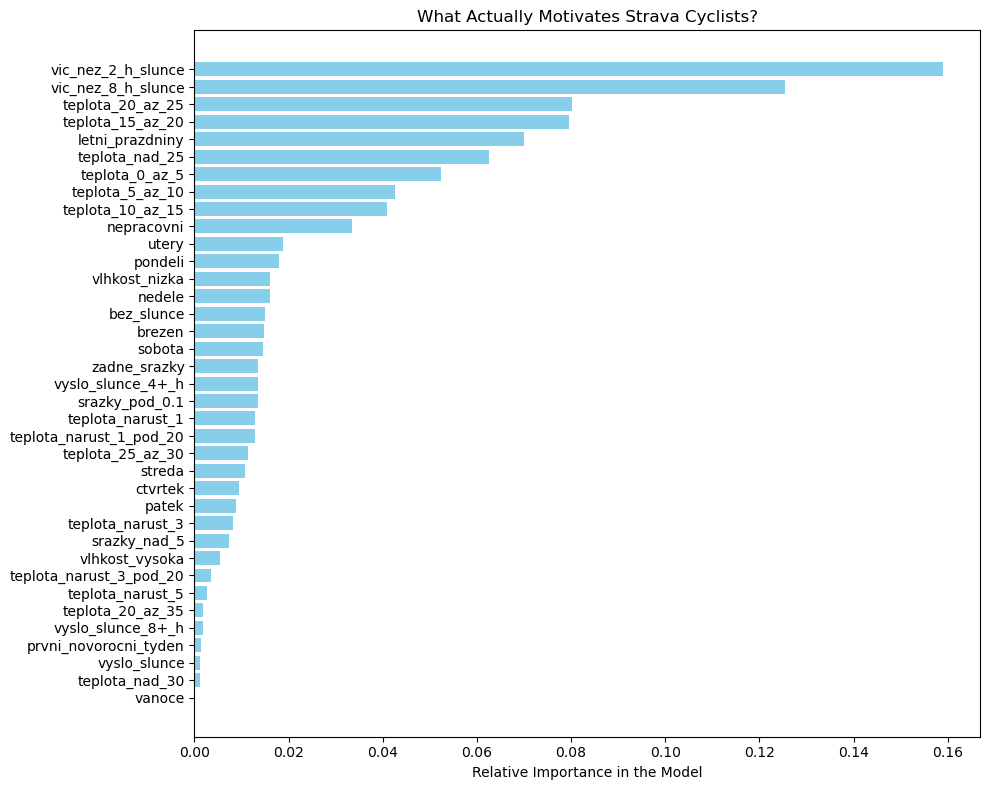

In [16]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title("What Actually Motivates Strava Cyclists?")
plt.xlabel("Relative Importance in the Model")
plt.tight_layout()
plt.show()

In [17]:
# Create a clean dataframe for math (drop NaNs so the calculator doesn't freak out)
df_corr = dfp.select(pl.col(
 'effort_diff',
 'srazky',
 'slunecni_svit',
 'teplota',
 'vlhkost')).to_pandas()

# 2. Calculate the Pearson Correlation Matrix
# This calculates how every single column moves in relation to every other column
correlation_matrix = df_corr.corr(method='pearson')

# 3. Isolate just the target variable (effort_diff)
# We don't need the whole massive grid, just how things relate to the runner count
target_corr = correlation_matrix['effort_diff'].drop('effort_diff')

# Sort them from strongest Motivator to strongest Barrier
target_corr_sorted = target_corr.sort_values(ascending=False)

# 4. Print the raw numbers for the stat nerds
print("--- STRONGEST MOTIVATORS (+1.0) ---")
print(target_corr_sorted.head(5))
print("\n--- STRONGEST BARRIERS (-1.0) ---")
print(target_corr_sorted.tail(5))

--- STRONGEST MOTIVATORS (+1.0) ---
teplota          0.790522
slunecni_svit    0.635161
srazky          -0.057719
vlhkost         -0.480246
Name: effort_diff, dtype: float64

--- STRONGEST BARRIERS (-1.0) ---
teplota          0.790522
slunecni_svit    0.635161
srazky          -0.057719
vlhkost         -0.480246
Name: effort_diff, dtype: float64


In [43]:
cols_to_check = features + ['effort_diff'] 

# Create a clean dataframe for math (drop NaNs so the calculator doesn't freak out)
df_corr = df_model[cols_to_check].to_pandas().dropna()

# 2. Calculate the Pearson Correlation Matrix
# This calculates how every single column moves in relation to every other column
correlation_matrix = df_corr.corr(method='pearson')

# 3. Isolate just the target variable (effort_diff)
# We don't need the whole massive grid, just how things relate to the runner count
target_corr = correlation_matrix['effort_diff'].drop('effort_diff')

# Sort them from strongest Motivator to strongest Barrier
target_corr_sorted = target_corr.sort_values(ascending=False)

# 4. Print the raw numbers for the stat nerds
print("--- STRONGEST MOTIVATORS (+1.0) ---")
print(target_corr_sorted.head(5))
print("\n--- STRONGEST BARRIERS (-1.0) ---")
print(target_corr_sorted.tail(5))

--- STRONGEST MOTIVATORS (+1.0) ---
vic_nez_8_h_slunce    0.546138
vic_nez_2_h_slunce    0.519173
teplota_nad_25        0.484090
letni_prazdniny       0.439731
teplota_25_az_30      0.431464
Name: effort_diff, dtype: float64

--- STRONGEST BARRIERS (-1.0) ---
teplota_10_az_15   -0.240722
vlhkost_vysoka     -0.264851
teplota_5_az_10    -0.293005
bez_slunce         -0.438756
teplota_0_az_5     -0.469265
Name: effort_diff, dtype: float64


In [59]:
korelace_graf = pl.concat(
    [
        pl.from_pandas(pd.DataFrame(target_corr_sorted.head(4)).reset_index()),
        pl.from_pandas(pd.DataFrame(target_corr_sorted.tail(4)).reset_index())   
    ]
).rename(
    {'effort_diff':'korelace s počtem jízd'}
)

hodnoty = korelace_graf.select(pl.col("index")).to_series().to_list()

korelace_graf = korelace_graf.with_columns(
    pl.col("index").str.replace_many(
        hodnoty,
        ['víc než 8 hodin slunce','víc než 2 hodiny slunce','teplota nad 25 °C','letní prázdniny','vlhkost vzduchu nad 89 %','teplota 5 až 10 °C','den bez slunce','teplota 0 až 5 °C']
    )
)

korelace_graf.write_json('data/korelace_cyklistika.json')

korelace_graf

index,korelace s počtem jízd
str,f64
"""víc než 8 hodin slunce""",0.546138
"""víc než 2 hodiny slunce""",0.519173
"""teplota nad 25 °C""",0.48409
"""letní prázdniny""",0.439731
"""vlhkost vzduchu nad 89 %""",-0.264851
"""teplota 5 až 10 °C""",-0.293005
"""den bez slunce""",-0.438756
"""teplota 0 až 5 °C""",-0.469265


In [18]:
alt.Chart(
    dfp
).mark_point(
).encode(
    alt.X('teplota:Q'),
    alt.Y('effort_diff:Q')
)

alt.Chart(...)

In [19]:
alt.Chart(
    dfp
).mark_point(
).encode(
    alt.X('slunecni_svit:Q'),
    alt.Y('effort_diff:Q')
)

alt.Chart(...)

In [20]:
alt.Chart(
    dfp
).mark_point(
).encode(
    alt.X('srazky:Q'),
    alt.Y('effort_diff:Q')
)

alt.Chart(...)

In [21]:
alt.Chart(
    dfp
).mark_point(
).encode(
    alt.X('vlhkost:Q'),
    alt.Y('effort_diff:Q')
)

alt.Chart(...)